In [37]:
import matplotlib.pyplot as plt
import pandas as pd
import scienceplots
import numpy as np

plt.style.use(['science', 'ieee', 'grid'])
plt.rcParams.update({"font.size": 12})

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
# sweep 9kzdsofv: https://wandb.ai/eth-iar/waam-e2e-footprint/sweeps/9kzdsofv?workspace=user-mglasder

In [60]:
df = pd.read_csv("data/sweep-9kzdsofv-train-data-frac-vs-val-loss.csv")

In [61]:
df

,Name,data_fraction,val_loss,_wandb
0,deep-sweep-7,0.1,0.180192,NaN
1,sage-sweep-6,0.2,0.157133,NaN
2,balmy-sweep-5,0.3,0.106323,NaN
3,polished-sweep-4,0.4,0.101818,NaN
4,wandering-sweep-3,0.6,0.089294,NaN
5,desert-sweep-2,0.8,0.091127,NaN
6,lucky-sweep-1,1.0,0.081324,NaN


In [62]:
# load uncertainties for each run
folders = ["20231127-145212-lucky-sweep-1"          ,
"20231127-145644-desert-sweep-2"                    ,
"20231127-150037-wandering-sweep-3"                 ,
"20231127-150433-polished-sweep-4"                  ,
"20231127-150830-balmy-sweep-5"                     ,
"20231127-151223-sage-sweep-6"                      ,
"20231127-151814-deep-sweep-7"                    ]
                                                    

In [63]:
from pathlib import Path

base = Path("/Users/magnus/repos/waam-footprint/fp/outputs/mc/")
mean_uncertainties = []
for folder in folders:
    df_uncert = pd.read_csv(base / folder / "uncertainties_calib.csv", header=None)
    arr = df_uncert.values.mean() * 0.1
    mean_uncertainties.append(arr)

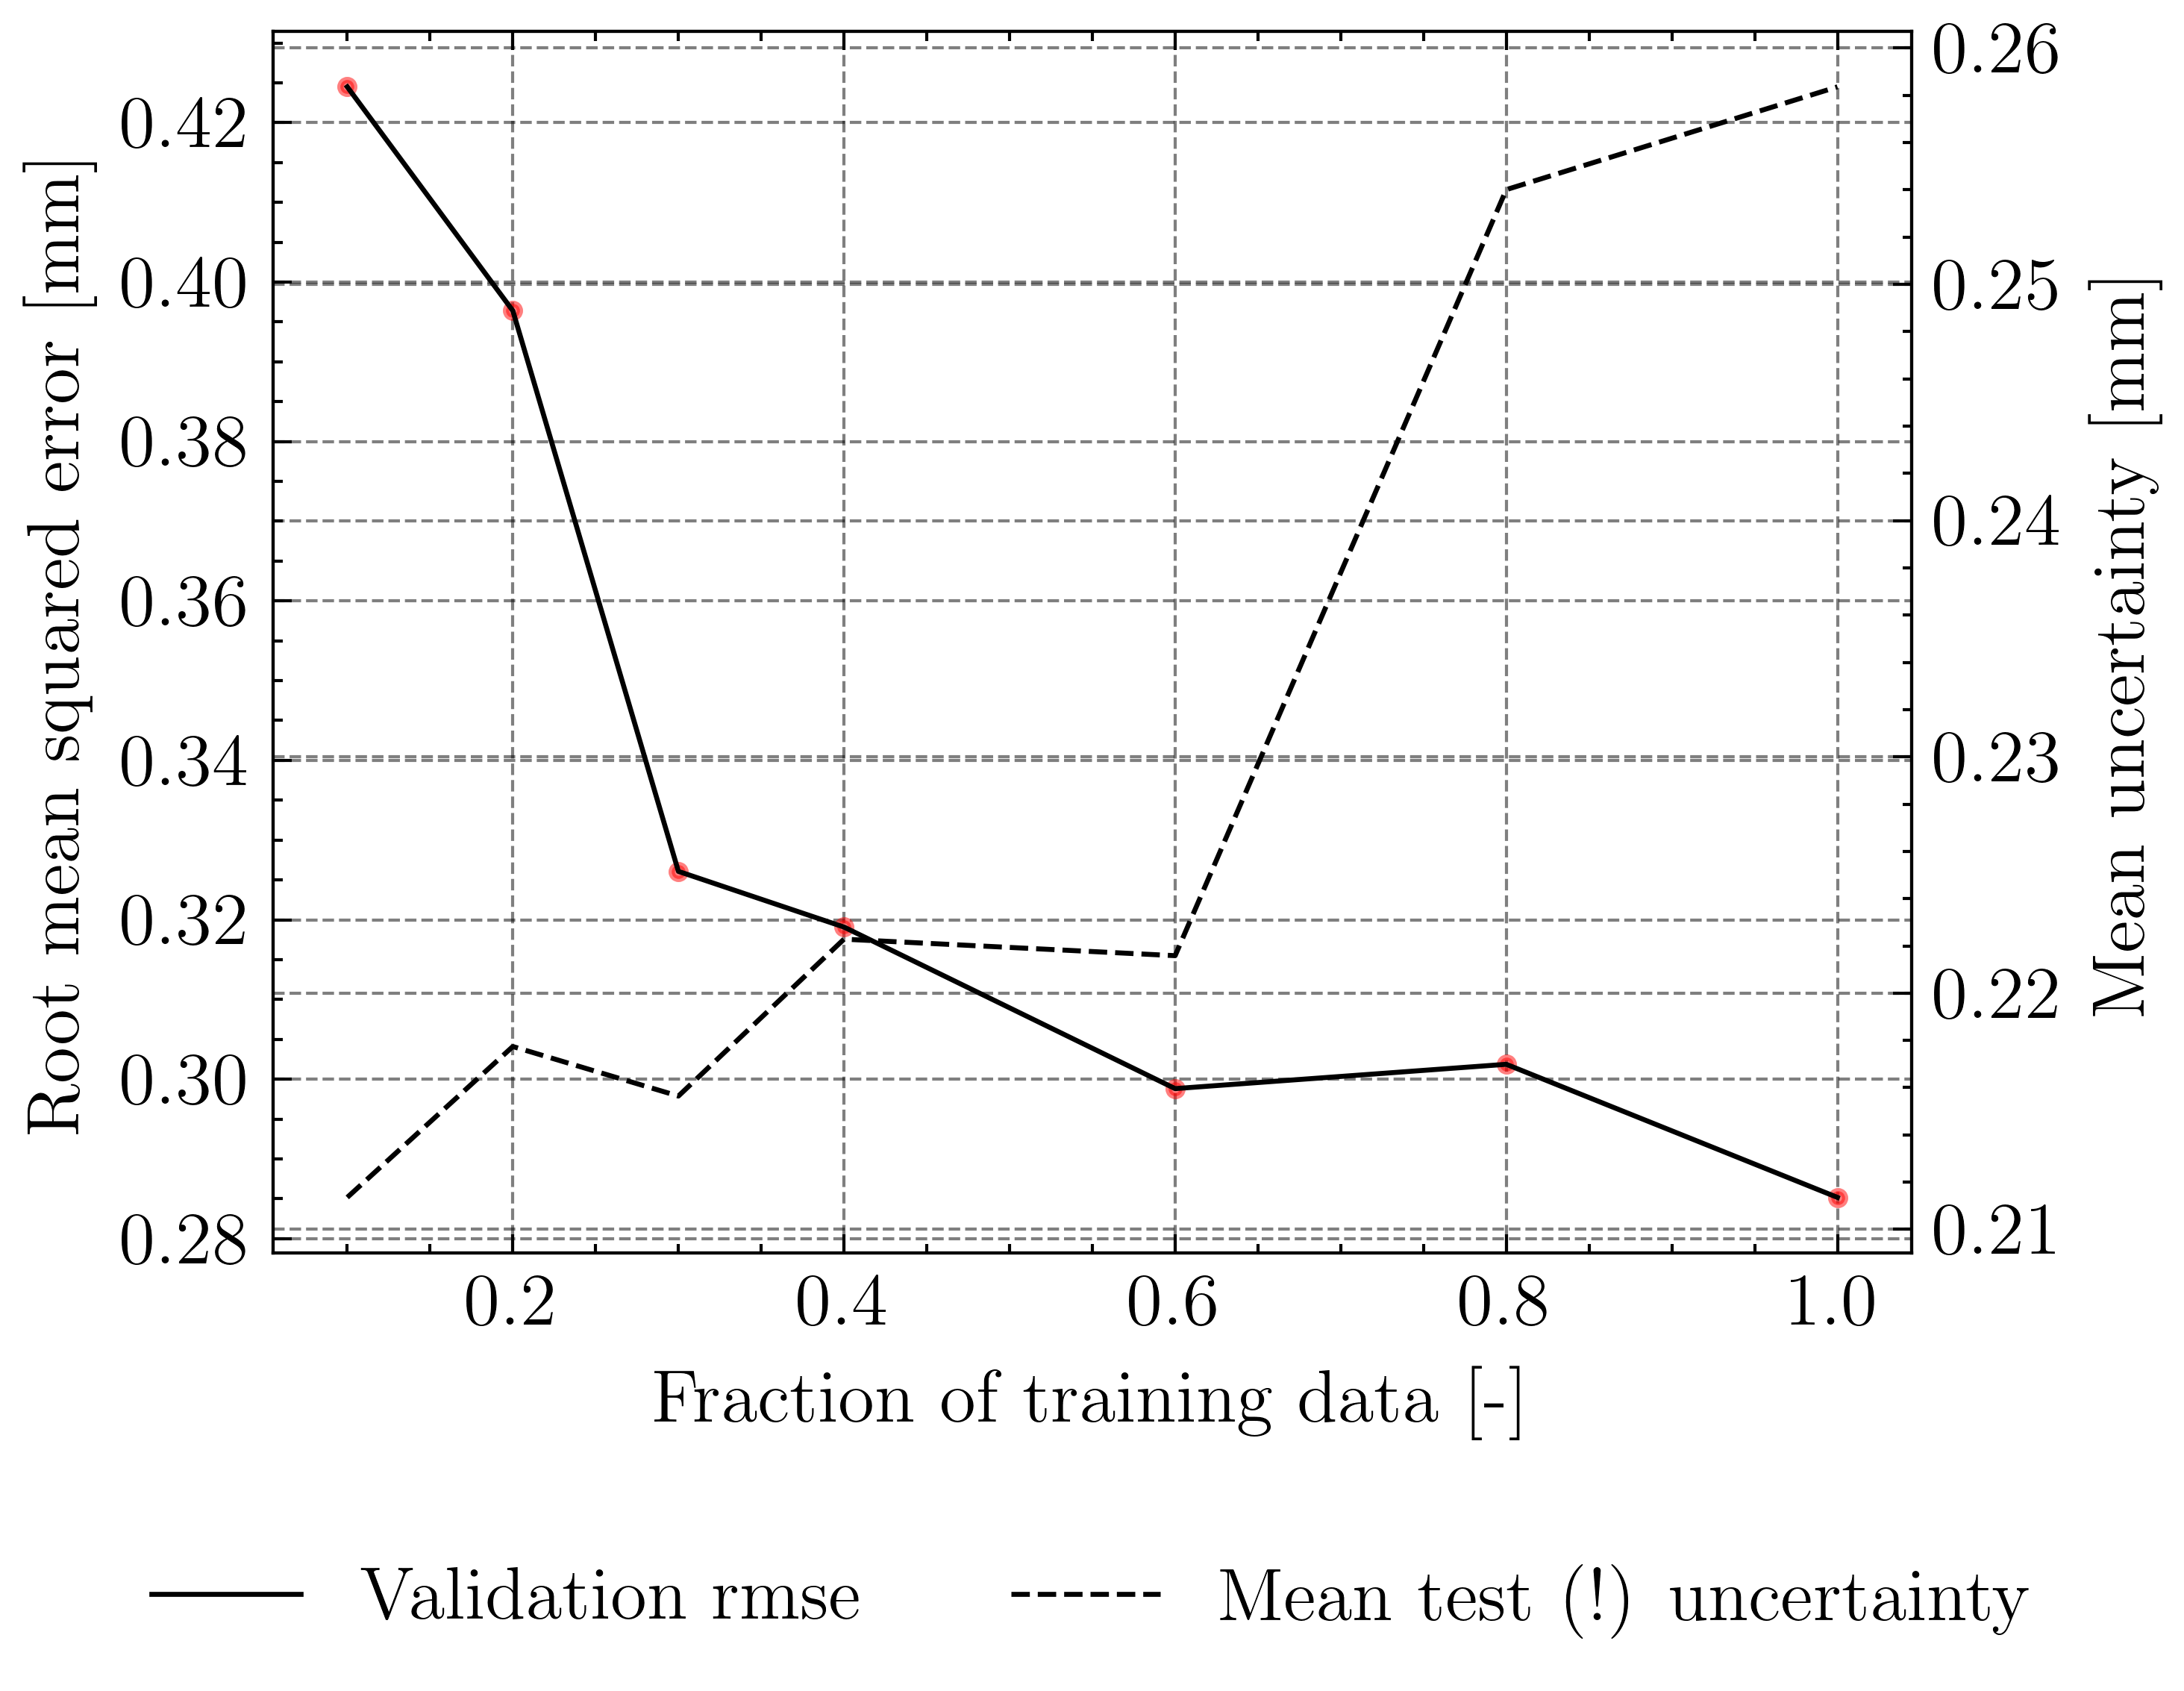

In [72]:

# plot data_fraction vs. val_loss
cm = 1 / 2.54
fig, ax = plt.subplots(figsize=(12 * cm, 9 * cm), dpi=600)
ax.plot(df["data_fraction"], np.sqrt(df["val_loss"].values), c="black", lw=0.8)
ax.scatter(df["data_fraction"], np.sqrt(df["val_loss"].values), marker="o", c="red", s=5, alpha=0.5)

# second y-axis on right
ax2 = ax.twinx()
ax2.plot([], [], lw=0.8, c="black", label="Validation rmse")
ax2.plot(df["data_fraction"], mean_uncertainties, lw=0.8, c="black", ls="--", label="Mean test (!) uncertainty")
ax.set_xlabel("Fraction of training data [-]")
ax.set_ylabel("Root mean squared error [mm]")
ax2.set_ylabel("Mean uncertainty [mm]")
# set aspect ratio to 1
# legend, below plot, no box
ax2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=False)
plt.show()